In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0007308.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0003491.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0010098.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0001966.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009925.jpg
/kaggle/input/d

## MediaPipe Hands Reference

Link:
https://github.com/google-ai-edge/mediapipe/blob/master/docs/solutions/hands.md

MediaPipe Hands will be used for palm/hand detection and landmark detection. It detects 21 hand landmarks and helps identify wrist, fingers, palm region, and hand orientation.

This will be used after EDA to check whether an image contains a detectable palm/hand or not.

In [7]:
!nvidia-smi

Thu Jul  9 13:54:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    if filenames:
        print(dirname, ":", len(filenames), "files")

/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset : 1 files
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands : 11076 files
/kaggle/input/datasets/lsind18/tarot-json : 1 files
/kaggle/input/datasets/lsind18/tarot-json/cards : 78 files


In [9]:
import os

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = []

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.lower().endswith(image_extensions):
            image_files.append(os.path.join(dirname, filename))

print("Total image files:", len(image_files))
print("First 10 image paths:")
for img in image_files[:10]:
    print(img)

Total image files: 11154
First 10 image paths:
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0007308.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0003491.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0010098.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0001966.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009925.jpg


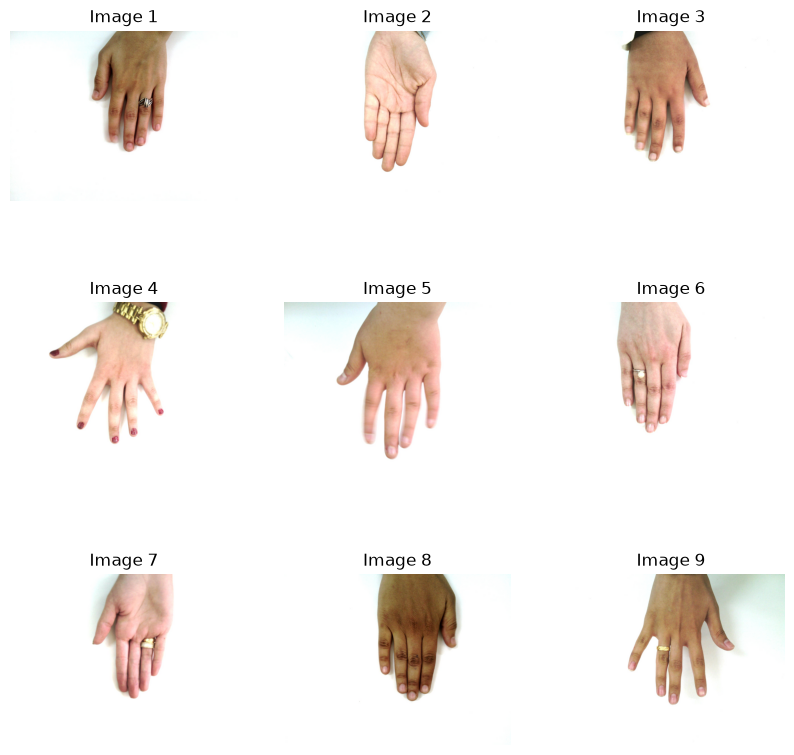

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

sample_images = image_files[:9]

plt.figure(figsize=(10, 10))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [11]:
import pandas as pd
from PIL import Image

image_info = []

for img_path in image_files[:500]:
    img = Image.open(img_path)
    image_info.append({
        "file_path": img_path,
        "width": img.size[0],
        "height": img.size[1],
        "mode": img.mode
    })

df = pd.DataFrame(image_info)
df.head()

,file_path,width,height,mode
0,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
1,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
2,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
3,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
4,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB


In [12]:
df[['width', 'height']].describe()

,width,height
count,500.0,500.0
mean,1600.0,1200.0
std,0.0,0.0
min,1600.0,1200.0
25%,1600.0,1200.0
50%,1600.0,1200.0
75%,1600.0,1200.0
max,1600.0,1200.0


# EDA Findings

I downloaded/added the Hands and Palm Images Dataset in Kaggle Notebook and performed initial EDA.

## Work Done
- Checked dataset file structure.
- Counted total image files.
- Displayed sample palm/hand images.
- Checked image size, width, height, and image format.

## Findings
- The dataset contains hand and palm images.
- The images are useful for palm image preprocessing, palm detection, and feature extraction.
- Some images may need preprocessing such as resizing, grayscale conversion, contrast enhancement, and noise removal before further analysis.

## Next Step
The next step is to build a palm image detector to check whether an uploaded image contains a palm/hand or not.

# Palm Image Detection

After completing EDA, the next step is to check whether an image contains a detectable palm/hand or not. For this, MediaPipe Hands will be used.

In [ ]:
!pip install mediapipe opencv-python

In [5]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

image_files = []

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.lower().endswith(image_extensions):
            image_files.append(os.path.join(dirname, filename))

print("Total images found:", len(image_files))
print(image_files[:5])

Total images found: 11154
['/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg']


In [ ]:
!pip install --upgrade --force-reinstall protobuf==4.25.8
!pip install --upgrade --force-reinstall mediapipe==0.10.14

In [1]:
import google.protobuf
print("Protobuf version:", google.protobuf.__version__)

Protobuf version: 4.25.9


In [2]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import os
from PIL import Image

print("MediaPipe version:", mp.__version__)

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("MediaPipe imported successfully")

MediaPipe version: 0.10.14
MediaPipe imported successfully


In [ ]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14 opencv-python

In [13]:
def detect_palm(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return "Image not loaded", None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.5
    ) as hands:

        results = hands.process(image_rgb)

        if results.multi_hand_landmarks:
            output_image = image_rgb.copy()

            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    output_image,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS
                )

            return "Palm Detected", output_image
        else:
            return "Palm Not Detected", image_rgb

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1783605318.883012     350 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605318.911057     350 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Result: Palm Detected


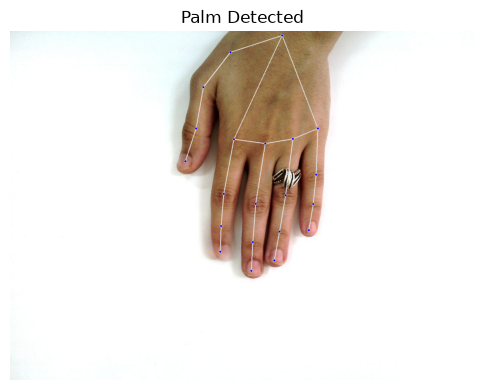

In [14]:
test_image = image_files[0]

result, output = detect_palm(test_image)

print("Result:", result)

plt.figure(figsize=(6, 6))
plt.imshow(output)
plt.axis("off")
plt.title(result)
plt.show()

W0000 00:00:1783605327.006627     352 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605327.034483     352 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605327.105101     358 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605327.119018     358 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605327.177270     362 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605327.195425     362 inference_feedback_manager.cc:114] Feedback manager 

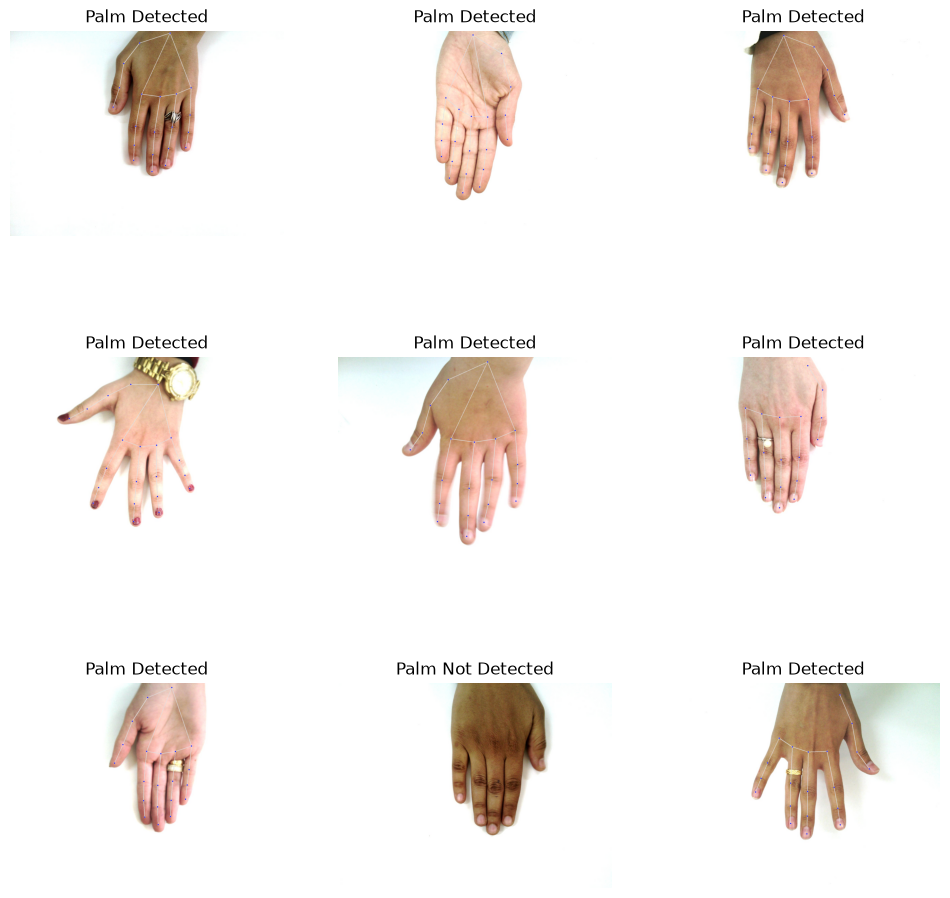

In [15]:
sample_images = image_files[:9]

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_images):
    result, output = detect_palm(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(output)
    plt.axis("off")
    plt.title(result)

plt.show()

# Palm Detection Findings

I tested palm/hand detection using MediaPipe Hands on sample images from the dataset.

## Findings
- MediaPipe successfully detected hand/palm regions in clear images.
- The detector marks hand landmarks such as wrist and finger points.
- Clear images give better detection results.
- Images with poor lighting, unclear hand position, or background noise may need preprocessing.

## Next Step
The next step is to improve preprocessing and extract palm-related features.

# Palm Image Preprocessing

After EDA and initial palm detection, preprocessing is applied to improve image quality before feature extraction.

In [16]:
import cv2
import matplotlib.pyplot as plt

def preprocess_palm_image(image_path):
    image = cv2.imread(image_path)
    
    if image is None:
        return None, None, None, None
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize
    resized = cv2.resize(image_rgb, (224, 224))
    
    # Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    
    # Histogram equalization for contrast improvement
    enhanced = cv2.equalizeHist(gray)
    
    # Edge detection
    edges = cv2.Canny(enhanced, 50, 150)
    
    return resized, gray, enhanced, edges

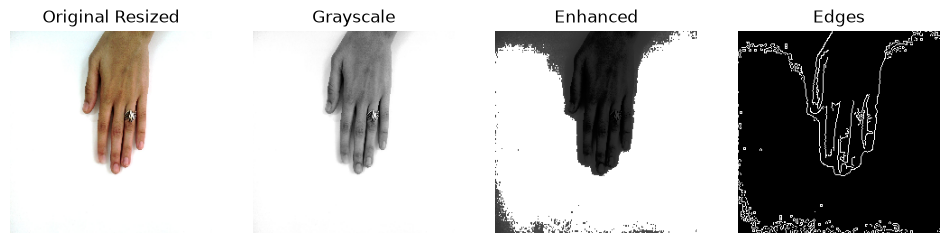

In [17]:
test_image = image_files[0]

resized, gray, enhanced, edges = preprocess_palm_image(test_image)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(resized)
plt.title("Original Resized")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.show()

# Preprocessing Findings

## Work Done
- Resized palm images to a fixed size.
- Converted images to grayscale.
- Applied contrast enhancement.
- Applied edge detection to observe palm/hand line structures.

## Findings
- Resizing helps make all images uniform.
- Grayscale conversion reduces image complexity.
- Contrast enhancement improves visibility of hand/palm regions.
- Edge detection helps highlight boundaries and line-like structures.

## Next Step
The next step is palm feature extraction using hand landmarks and image processing techniques.

In [18]:
import math
import pandas as pd

def extract_palm_features(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image_rgb.shape

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.5
    ) as hands:

        results = hands.process(image_rgb)

        if not results.multi_hand_landmarks:
            return {
                "image_path": image_path,
                "palm_detected": False
            }

        landmarks = results.multi_hand_landmarks[0].landmark

        wrist = landmarks[0]
        index_mcp = landmarks[5]
        pinky_mcp = landmarks[17]
        middle_tip = landmarks[12]

        wrist_x, wrist_y = wrist.x * width, wrist.y * height
        index_x, index_y = index_mcp.x * width, index_mcp.y * height
        pinky_x, pinky_y = pinky_mcp.x * width, pinky_mcp.y * height
        middle_x, middle_y = middle_tip.x * width, middle_tip.y * height

        palm_width = math.sqrt((index_x - pinky_x)**2 + (index_y - pinky_y)**2)
        hand_length = math.sqrt((middle_x - wrist_x)**2 + (middle_y - wrist_y)**2)

        palm_center_x = (index_x + pinky_x + wrist_x) / 3
        palm_center_y = (index_y + pinky_y + wrist_y) / 3

        return {
            "image_path": image_path,
            "palm_detected": True,
            "image_width": width,
            "image_height": height,
            "palm_width": palm_width,
            "hand_length": hand_length,
            "palm_center_x": palm_center_x,
            "palm_center_y": palm_center_y
        }

In [19]:
features = []

for img_path in image_files[:20]:
    result = extract_palm_features(img_path)
    features.append(result)

features_df = pd.DataFrame(features)
features_df.head()

W0000 00:00:1783605352.398161     389 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605352.411533     389 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605352.458053     392 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605352.479706     392 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605352.527611     398 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783605352.541891     398 inference_feedback_manager.cc:114] Feedback manager 

,image_path,palm_detected,image_width,image_height,palm_width,hand_length,palm_center_x,palm_center_y
0,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,291.229296,816.861327,922.369035,240.409267
1,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,270.277961,925.049438,764.188242,308.178151
2,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,301.834871,859.564160,684.220171,256.553638
3,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,283.819799,814.272263,822.451448,374.884570
4,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,378.283947,1027.343596,855.833435,313.934600


In [20]:
features_df.describe()

,image_width,image_height,palm_width,hand_length,palm_center_x,palm_center_y
count,19.0,19.0,19.000000,19.000000,19.000000,19.000000
mean,1600.0,1200.0,323.252902,913.629617,790.946512,271.578402
std,0.0,0.0,38.955509,94.600051,100.030885,76.271712
min,1600.0,1200.0,264.726572,801.279998,624.109030,146.122944
25%,1600.0,1200.0,291.635194,822.102331,726.069236,230.137065
50%,1600.0,1200.0,313.735151,902.355675,801.945210,254.011416
75%,1600.0,1200.0,353.749202,976.066338,845.090413,311.056376
max,1600.0,1200.0,385.106627,1089.826499,969.677782,494.048882


# Palm Feature Extraction Findings

I extracted basic palm/hand features using MediaPipe landmarks.

## Work Done
- Detected palm/hand landmarks using MediaPipe.
- Extracted wrist point, index finger base, pinky finger base, and middle finger tip.
- Calculated palm width, hand length, and palm center.

## Findings
- Basic palm geometry can be extracted from clear detected images.
- Palm width and hand length can be used as initial features for palm structure analysis.
- Images where MediaPipe cannot detect the hand need preprocessing or filtering.

## Next Step
The next step is to connect extracted palm features with palmistry-based interpretation logic.

# Final Summary of Current Work

## Work Completed
- Added the given palm and tarot datasets in Kaggle Notebook.
- Connected GPU and verified GPU availability.
- Performed initial EDA on the palm image dataset.
- Displayed sample palm/hand images.
- Checked image file paths, image size, and image format.
- Installed and tested MediaPipe Hands.
- Built an initial palm detector to check whether an image contains a palm/hand.
- Applied basic preprocessing such as resizing, grayscale conversion, contrast enhancement, and edge detection.
- Extracted basic palm/hand features using MediaPipe landmarks.

## Key Findings
- The palm dataset contains usable hand/palm images for preprocessing and feature extraction.
- MediaPipe successfully detects clear palm/hand images.
- Hand landmarks can be used to extract palm width, hand length, palm center, wrist point, and finger points.
- Some images may need preprocessing because detection can be affected by lighting, background, and hand position.

## Next Step
The next step is to connect extracted palm features with palmistry interpretation logic and later integrate tarot card data for combined palmistry and tarot insights.

# Palmar Side Filtering

For palmistry line detection, only the front side of the hand is useful because palm lines are visible only on the palmar side. Backside hand images should be filtered out before palm line detection.

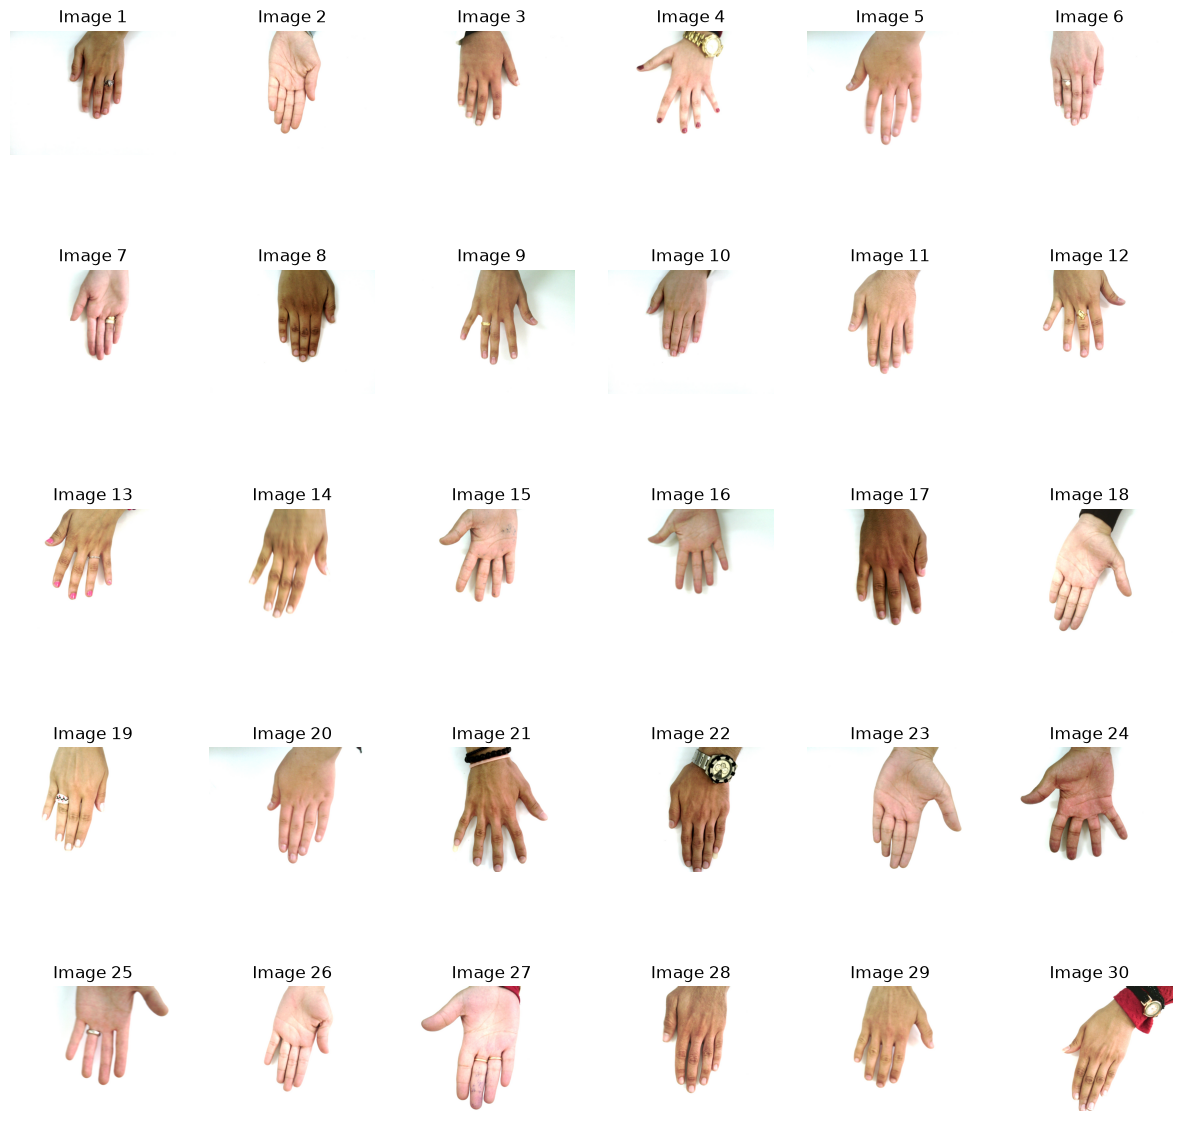

In [24]:
sample_images = image_files[:30]

plt.figure(figsize=(15, 15))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(5, 6, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [61]:
def detect_dark_palm_lines(palm_crop):
    if palm_crop is None:
        return None, None, None, None

    # Resize
    resized = cv2.resize(palm_crop, (300, 300))

    # Convert to grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

    # Improve local contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Smooth image slightly
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    # Black-hat filter highlights dark lines on lighter skin
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    blackhat = cv2.morphologyEx(blurred, cv2.MORPH_BLACKHAT, kernel)

    # Threshold only stronger dark line structures
    _, thresh = cv2.threshold(
        blackhat, 
        0, 
        255, 
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Remove small noise
    noise_kernel = np.ones((2, 2), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, noise_kernel)

    return resized, enhanced, blackhat, cleaned

W0000 00:00:1783607311.311483     646 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783607311.324726     647 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


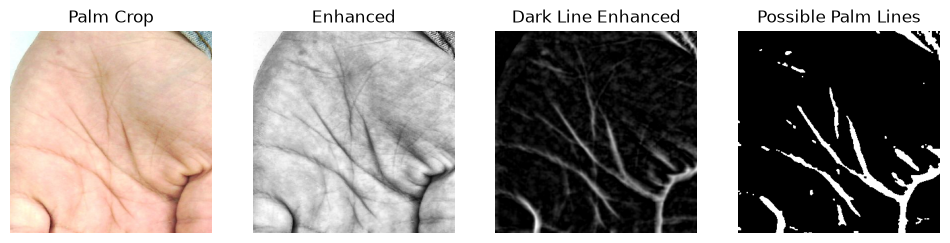

In [62]:
test_image = image_files[1]

palm_crop = crop_palm_region(test_image)

resized, enhanced, blackhat, cleaned_lines = detect_dark_palm_lines(palm_crop)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(resized)
plt.title("Palm Crop")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(blackhat, cmap="gray")
plt.title("Dark Line Enhanced")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cleaned_lines, cmap="gray")
plt.title("Possible Palm Lines")
plt.axis("off")

plt.show()

# Palmar Side Filtering Result

After improving preprocessing, the selected image was correctly classified as a possible palmar-side image. The palm crop shows the front side of the hand where palm lines are visible.

The enhanced image improves visibility of palm line structures, and the cleaned edge image highlights possible line patterns. This confirms that only palmar-side images should be used for further palm line detection.

However, the detected edges still include some noise and skin texture. Therefore, this is an initial palm line detection step, not final heart line, head line, or life line classification.

# Updated Work After Feature Extraction

After palm feature extraction, I added palmar-side filtering because palmistry lines are visible only on the front side of the hand.

## Work Done
- Displayed sample dataset images.
- Observed that the dataset contains both front palm-side and backside hand images.
- Tested palm-side filtering using OpenCV.
- Improved preprocessing because the first edge output was too noisy.
- Used CLAHE, lower Canny threshold, and morphological closing to preserve visible palm lines.
- Successfully identified a possible palmar-side image and highlighted possible palm line structures.

## Findings
- Backside hand images are not useful for palmistry line detection.
- Only front palm-side images should be used for heart line, head line, life line, and other line detection.
- OpenCV can highlight possible palm line structures, but the output still contains some noise.
- This is an initial palm line detection step, not final line classification.
- For accurate heart line, head line, life line, and moon line detection, we need region-based logic or manually labeled palm-line data.

## Next Step
The next step is to classify detected line structures into possible palmistry line regions such as heart line, head line, life line, fate line, and moon line.

## Final Summary of Current Work

### Work Completed

* Added the given palm and tarot datasets in Kaggle Notebook.
* Connected GPU and verified GPU availability.
* Performed initial EDA on the palm image dataset.
* Displayed sample palm/hand images.
* Checked image file paths, image size, and image format.
* Installed and tested MediaPipe Hands.
* Built an initial palm detector to check whether an image contains a palm/hand.
* Applied basic preprocessing such as resizing, grayscale conversion, contrast enhancement, and edge detection.
* Extracted basic palm/hand features using MediaPipe landmarks.
* Displayed multiple sample images and observed that the dataset contains both front palm-side images and backside hand images.
* Added palmar-side filtering because palmistry lines are visible only on the front side of the hand.
* Improved image preprocessing using grayscale conversion, CLAHE contrast enhancement, Gaussian blur, black-hat filtering, thresholding, and noise removal.
* Enhanced possible dark palm line structures from the selected palmar-side image.
* Generated a possible palm line mask to highlight visible line patterns.

### Key Findings

* The palm dataset contains usable hand/palm images for preprocessing and feature extraction.
* The dataset includes both palmar-side images and backside hand images.
* Backside hand images are not useful for palmistry line detection because heart line, head line, life line, fate line, and moon line are visible only on the front palm side.
* MediaPipe successfully detects clear palm/hand images.
* Hand landmarks can be used to extract palm width, hand length, palm center, wrist point, and finger points.
* Some images may need preprocessing because detection can be affected by lighting, background, image quality, and hand position.
* Basic edge detection alone was not suitable because it detected general edges, shadows, background noise, and skin texture.
* Black-hat filtering and contrast enhancement gave better results for highlighting darker palm line structures.
* The current result shows **possible palm line structures**, but it is not final heart line, head line, life line, or moon line classification.